# Analyse MRIqc results
VPMB dataset after spin-echo distortion correction

Some guides:
- https://towardsdatascience.com/statsannotations-add-statistical-significance-annotations-on-seaborn-plots-6b753346a42a

In [1]:
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")
from itertools import combinations
from statannotations.Annotator import Annotator
import os

In [2]:
# dataset path
wd = os.path.abspath('..')
mriqc_data_file = os.path.join(wd, 'data', 'mriqc_group_bold.tsv')

# import tsv file
mriqc_data = pandas.read_csv(mriqc_data_file, sep='\t')

In [3]:
# view
mriqc_data.head()

,bids_name,aor,aqi,dummy_trs,dvars_nstd,dvars_std,dvars_vstd,efc,fber,fd_mean,...,summary_bg_stdv,summary_fg_k,summary_fg_mad,summary_fg_mean,summary_fg_median,summary_fg_n,summary_fg_p05,summary_fg_p95,summary_fg_stdv,tsnr
0,sub-01_task-AA_acq-0500_run-1_bold,0.000380,0.012249,0,38.513725,1.184230,1.000107,0.559338,2739.041504,0.135953,...,851.424866,1.649877,1475.115367,9509.383789,9454.779297,55810.0,7194.165796,12113.792725,1575.965332,44.324478
1,sub-01_task-AA_acq-0750_run-1_bold,0.003095,0.018335,0,31.113940,1.157902,1.005471,0.573185,1964.504272,0.173606,...,1054.709961,1.629401,1719.699849,11489.869141,11414.047852,55209.0,8800.758789,14522.333984,1835.968140,41.413017
2,sub-01_task-AA_acq-1000_run-1_bold,0.002101,0.010108,0,26.585327,1.147315,1.024456,0.562032,2195.935791,0.183129,...,1150.837036,1.888404,1989.607294,12697.009766,12607.363281,55857.0,9533.901367,16235.122070,2160.396729,53.205177
3,sub-01_task-AA_acq-2500_run-1_bold,0.000578,0.003224,0,32.594990,1.197928,0.989386,0.577387,235.130478,0.055899,...,1708.341919,2.871521,5049.588236,14477.243164,13280.972656,55918.0,7387.377246,25994.709277,5953.833984,53.576714
4,sub-01_task-UA_acq-0500_run-1_bold,0.000574,0.012481,4,38.444725,1.185641,1.003976,0.559465,2759.964600,0.142584,...,856.946716,1.579121,1462.826708,9500.787109,9440.989258,55694.0,7207.778442,12120.166553,1565.237061,43.777832


In [4]:
# define TR pairs (for stat analysis)
TRs = ['500', '750', '1000', '2500']
TR_pairs = list(combinations(TRs, r=2))

# def get_var_per_tr(df: pandas.DataFrame, tr: str, var: str):
#     return df.loc[(df.TR == tr), "snr"].values

# add column to mriqc_data with TR based on bids_name if contains acq-0500
mriqc_data.loc[mriqc_data['bids_name'].str.contains('acq-0500'), 'TR'] = '500'
mriqc_data.loc[mriqc_data['bids_name'].str.contains('acq-0750'), 'TR'] = '750'
mriqc_data.loc[mriqc_data['bids_name'].str.contains('acq-1000'), 'TR'] = '1000'
mriqc_data.loc[mriqc_data['bids_name'].str.contains('acq-2500'), 'TR'] = '2500'

# check
mriqc_data.head()

,bids_name,aor,aqi,dummy_trs,dvars_nstd,dvars_std,dvars_vstd,efc,fber,fd_mean,...,summary_fg_k,summary_fg_mad,summary_fg_mean,summary_fg_median,summary_fg_n,summary_fg_p05,summary_fg_p95,summary_fg_stdv,tsnr,TR
0,sub-01_task-AA_acq-0500_run-1_bold,0.000380,0.012249,0,38.513725,1.184230,1.000107,0.559338,2739.041504,0.135953,...,1.649877,1475.115367,9509.383789,9454.779297,55810.0,7194.165796,12113.792725,1575.965332,44.324478,500
1,sub-01_task-AA_acq-0750_run-1_bold,0.003095,0.018335,0,31.113940,1.157902,1.005471,0.573185,1964.504272,0.173606,...,1.629401,1719.699849,11489.869141,11414.047852,55209.0,8800.758789,14522.333984,1835.968140,41.413017,750
2,sub-01_task-AA_acq-1000_run-1_bold,0.002101,0.010108,0,26.585327,1.147315,1.024456,0.562032,2195.935791,0.183129,...,1.888404,1989.607294,12697.009766,12607.363281,55857.0,9533.901367,16235.122070,2160.396729,53.205177,1000
3,sub-01_task-AA_acq-2500_run-1_bold,0.000578,0.003224,0,32.594990,1.197928,0.989386,0.577387,235.130478,0.055899,...,2.871521,5049.588236,14477.243164,13280.972656,55918.0,7387.377246,25994.709277,5953.833984,53.576714,2500
4,sub-01_task-UA_acq-0500_run-1_bold,0.000574,0.012481,4,38.444725,1.185641,1.003976,0.559465,2759.964600,0.142584,...,1.579121,1462.826708,9500.787109,9440.989258,55694.0,7207.778442,12120.166553,1565.237061,43.777832,500


In [5]:
# remove all rows of mriqc_data with TR = 2500
mriqc_data_mb = mriqc_data[mriqc_data.TR != '2500']

TRs_mb = ['500', '750', '1000']
TR_pairs_mb = list(combinations(TRs_mb, r=2))

mriqc_data_mb

,bids_name,aor,aqi,dummy_trs,dvars_nstd,dvars_std,dvars_vstd,efc,fber,fd_mean,...,summary_fg_k,summary_fg_mad,summary_fg_mean,summary_fg_median,summary_fg_n,summary_fg_p05,summary_fg_p95,summary_fg_stdv,tsnr,TR
0,sub-01_task-AA_acq-0500_run-1_bold,0.000380,0.012249,0,38.513725,1.184230,1.000107,0.559338,2739.041504,0.135953,...,1.649877,1475.115367,9509.383789,9454.779297,55810.0,7194.165796,12113.792725,1575.965332,44.324478,500
1,sub-01_task-AA_acq-0750_run-1_bold,0.003095,0.018335,0,31.113940,1.157902,1.005471,0.573185,1964.504272,0.173606,...,1.629401,1719.699849,11489.869141,11414.047852,55209.0,8800.758789,14522.333984,1835.968140,41.413017,750
2,sub-01_task-AA_acq-1000_run-1_bold,0.002101,0.010108,0,26.585327,1.147315,1.024456,0.562032,2195.935791,0.183129,...,1.888404,1989.607294,12697.009766,12607.363281,55857.0,9533.901367,16235.122070,2160.396729,53.205177,1000
4,sub-01_task-UA_acq-0500_run-1_bold,0.000574,0.012481,4,38.444725,1.185641,1.003976,0.559465,2759.964600,0.142584,...,1.579121,1462.826708,9500.787109,9440.989258,55694.0,7207.778442,12120.166553,1565.237061,43.777832,500
5,sub-01_task-UA_acq-0750_run-1_bold,0.001116,0.010334,2,30.491941,1.189368,1.019548,0.572487,2013.739624,0.154765,...,1.733263,1738.962095,11452.496094,11389.122070,55293.0,8736.403125,14537.389453,1866.217285,51.744461,750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,sub-23_task-AA_acq-1000_run-1_bold,0.000757,0.007971,0,35.979749,1.340586,1.012246,0.572480,1728.311523,0.172894,...,1.759824,1785.157317,10973.993164,10914.679688,59787.0,8109.575439,14165.285059,1920.666992,56.373020,1000
130,sub-23_task-UA_acq-0500_run-1_bold,0.000330,0.013377,1,41.706546,1.246363,0.999954,0.566998,2496.776367,0.159563,...,1.694318,1283.537533,8060.681641,8034.580078,59370.0,6021.878564,10298.995361,1369.868774,42.009518,500
131,sub-23_task-UA_acq-0750_run-1_bold,0.000686,0.010823,1,32.365019,1.200987,1.005610,0.581483,1889.413330,0.165878,...,1.810520,1519.552170,9768.498047,9727.887695,58930.0,7309.600293,12466.100293,1632.811035,50.482101,750
132,sub-23_task-UA_acq-1000_run-1_bold,0.000436,0.007820,0,36.057167,1.337162,1.000895,0.573209,1696.746216,0.170595,...,1.809411,1783.813708,10971.371094,10912.480469,59910.0,8108.440479,14149.959717,1919.774170,57.184803,1000


# SNR (Signal to noise ratio)
The estimation may be provided with only one foreground region in which the noise is computed as follows:

$$ SNR = \frac{\mu_F}{\sigma _F \sqrt{\frac{n}{n-1}}} $$

where $\mu_F$ is the mean intensity of the foreground and $\sigma_F$ is the standard deviation of the same region. Higher values are better.

In [6]:
# estimate mean and std of snr for each TR and print them
snr_mean = mriqc_data_mb.groupby('TR')['snr'].mean()
snr_std = mriqc_data_mb.groupby('TR')['snr'].std()

print('snr mean per TR:')
print(snr_mean)
print('snr std per TR:')
print(snr_std)

snr mean per TR:
TR
1000    6.120141
500     6.211847
750     6.344375
Name: snr, dtype: float64
snr std per TR:
TR
1000    0.422521
500     0.392705
750     0.395373
Name: snr, dtype: float64


p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.783e-01 U_stat=3.220e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.469e-02 U_stat=9.090e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:7.090e-01 U_stat=7.850e+02


(<Axes: xlabel='TR (milliseconds)', ylabel='SNR'>,
  <statannotations.Annotation.Annotation at 0x7f3415187390>])

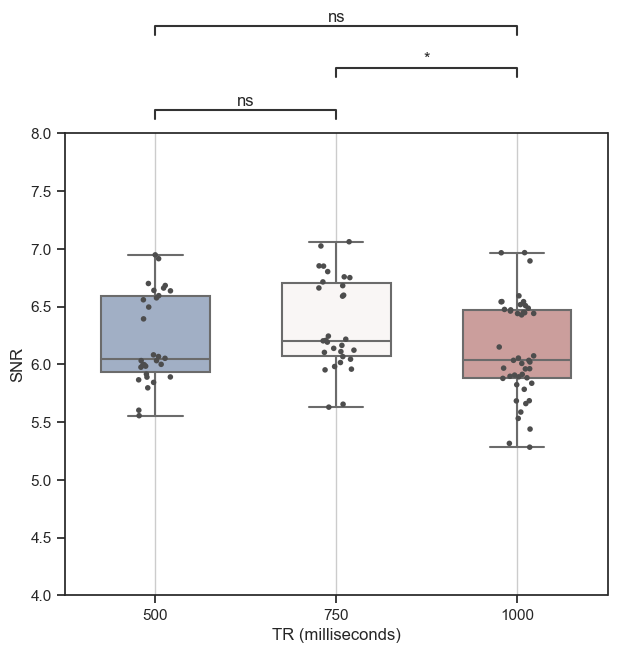

In [7]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(x="TR", y="snr", data=mriqc_data_mb,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="TR", y="snr", data=mriqc_data_mb,
              size=4, color=".3", linewidth=0)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="SNR", ylim=(4,8))
#sns.despine(trim=True, left=True)

annotator = Annotator(ax, TR_pairs_mb, data=mriqc_data_mb, x='TR', y='snr', order=TRs_mb)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni')
annotator.apply_and_annotate()

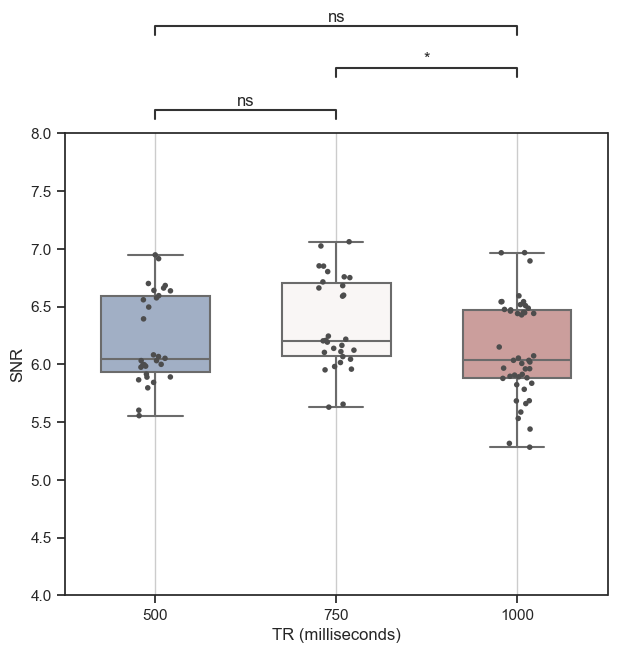

In [8]:
#| label: mriqc_snr
f

# Temporal SNR
We report the median value of the tSNR map calculated like:

$$ tSNR = \frac{S_t}{\sigma_t} $$

where $S_t$ is the average BOLD signal (across time), and $\sigma_t$ is the corresponding temporal standard-deviation map. Higher values are better.

In [14]:
# estimate mean and std of tsnr for each TR and print them
tsnr_mean = mriqc_data.groupby('TR')['tsnr'].mean()
tsnr_std = mriqc_data.groupby('TR')['tsnr'].std()

print('tsnr mean per TR:')
print(tsnr_mean)
print('tsnr std per TR:')
print(tsnr_std)

tsnr mean per TR:
TR
1000    52.901860
2500    46.825849
500     40.767411
750     48.639979
Name: tsnr, dtype: float64
tsnr std per TR:
TR
1000    7.735960
2500    9.780532
500     5.365092
750     6.873544
Name: tsnr, dtype: float64


p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.111e-06 U_stat=1.100e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.212e-02 U_stat=4.060e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:9.359e-03 U_stat=9.680e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:7.557e-09 U_stat=1.130e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.830e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.298e-04 U_stat=1.710e+02


(<Axes: xlabel='TR (milliseconds)', ylabel='tSNR'>,
  <statannotations.Annotation.Annotation at 0x7f3413b3fb50>])

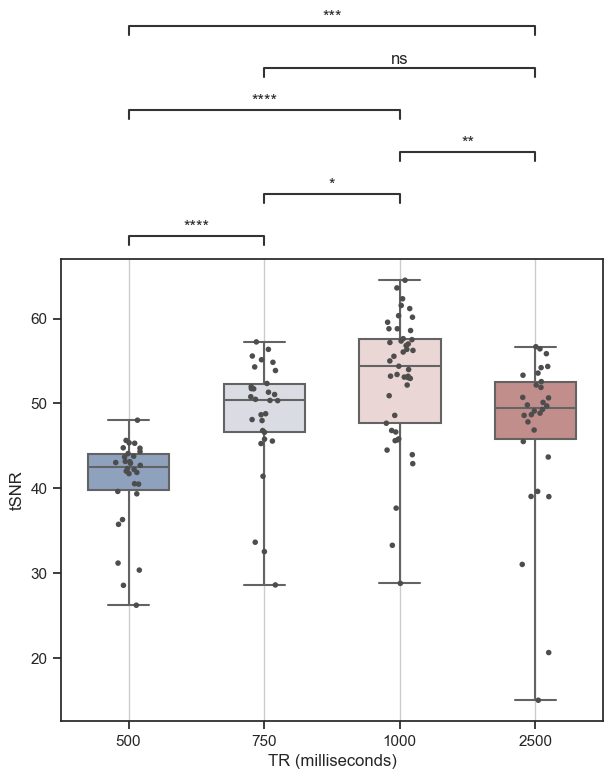

In [12]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(x="TR", y="tsnr", data=mriqc_data,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="TR", y="tsnr", data=mriqc_data,
              size=4, color=".3", linewidth=0)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="tSNR")
#sns.despine(trim=True, left=True)

annotator = Annotator(ax, TR_pairs, data=mriqc_data, x='TR', y='tsnr', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni')
annotator.apply_and_annotate()

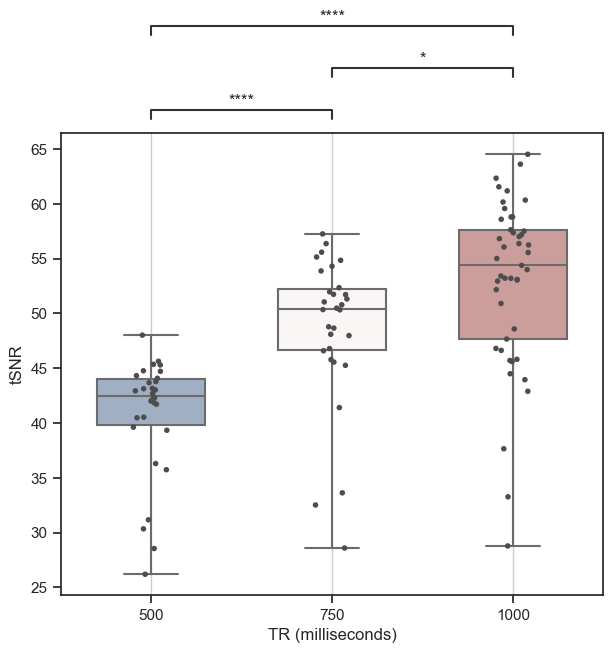

In [41]:
#| label: mriqc_tsnr
f

# AQI (AFNI’s quality index)
Mean quality index as computed by AFNI’s 3dTqual; for each volume, it is one minus the Spearman’s (rank) correlation of that volume with the median volume. Lower values are better.

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:7.140e-03 U_stat=6.560e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.345e-01 U_stat=8.610e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:6.888e-05 U_stat=1.067e+03


(<Axes: xlabel='TR (milliseconds)', ylabel='AQI'>,
  <statannotations.Annotation.Annotation at 0x13ff45990>])

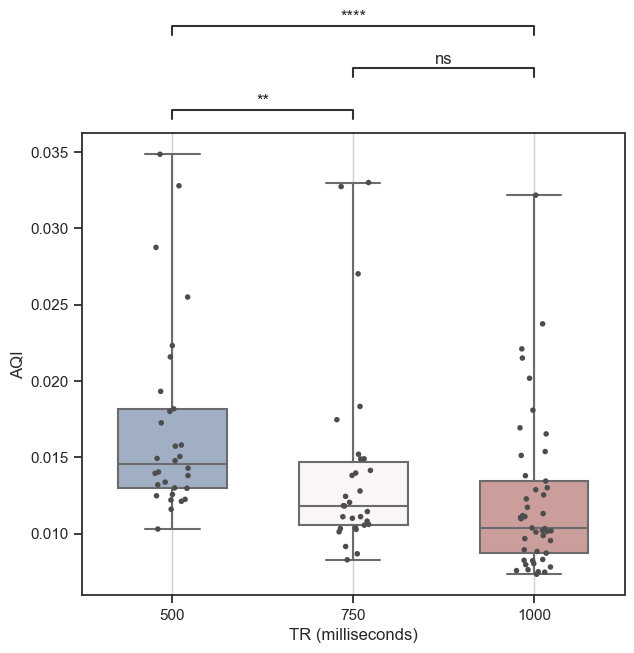

In [34]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(x="TR", y="aqi", data=mriqc_data_mb,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="TR", y="aqi", data=mriqc_data_mb,
              size=4, color=".3", linewidth=0)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="AQI")
#sns.despine(trim=True, left=True)

annotator = Annotator(ax, TR_pairs_mb, data=mriqc_data_mb, x='TR', y='aqi', order=TRs_mb)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni')
annotator.apply_and_annotate()


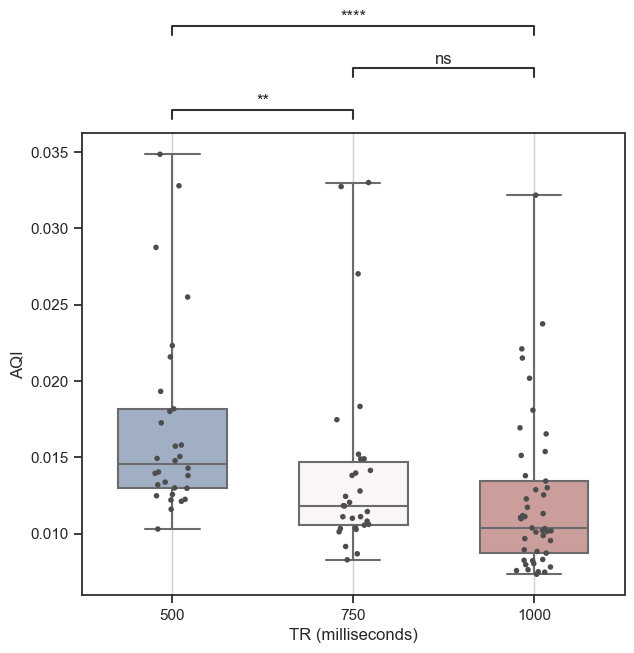

In [35]:
#| label: mriqc_aqi
f

# FWHM (Full-width half-maximum smoothness)
The FWHM of the spatial distribution of the image intensity values in units of voxels.
Lower values are better, higher values indicate a blurrier image. 

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.871e-01 U_stat=5.450e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=7.120e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.528e-01 U_stat=8.560e+02


(<Axes: xlabel='TR (milliseconds)', ylabel='FWHM (average)'>,
  <statannotations.Annotation.Annotation at 0x16c1647d0>])

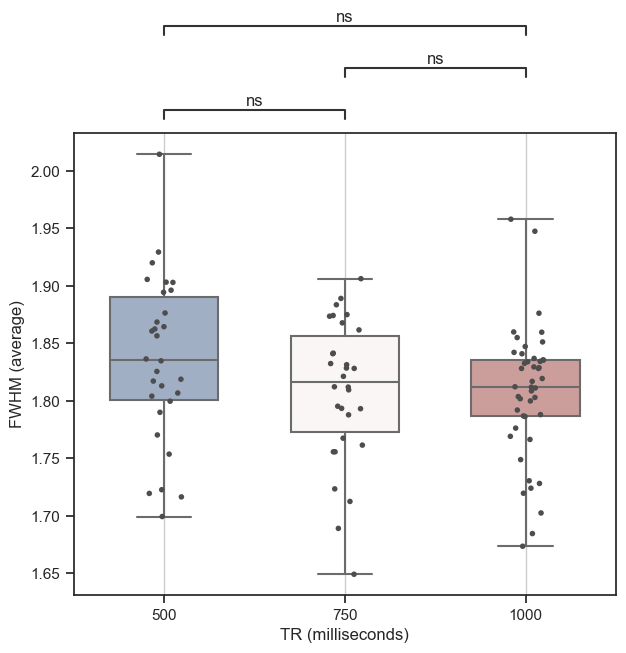

In [37]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(x="TR", y="fwhm_avg", data=mriqc_data_mb,
            whis=[0, 100], width=.6, palette="vlag")

# Add in points to show each observation
sns.stripplot(x="TR", y="fwhm_avg", data=mriqc_data_mb,
              size=4, color=".3", linewidth=0)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="FWHM (average)")
#sns.despine(trim=True, left=True)

annotator = Annotator(ax, TR_pairs_mb, data=mriqc_data_mb, x='TR', y='fwhm_avg', order=TRs_mb)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni')
annotator.apply_and_annotate()


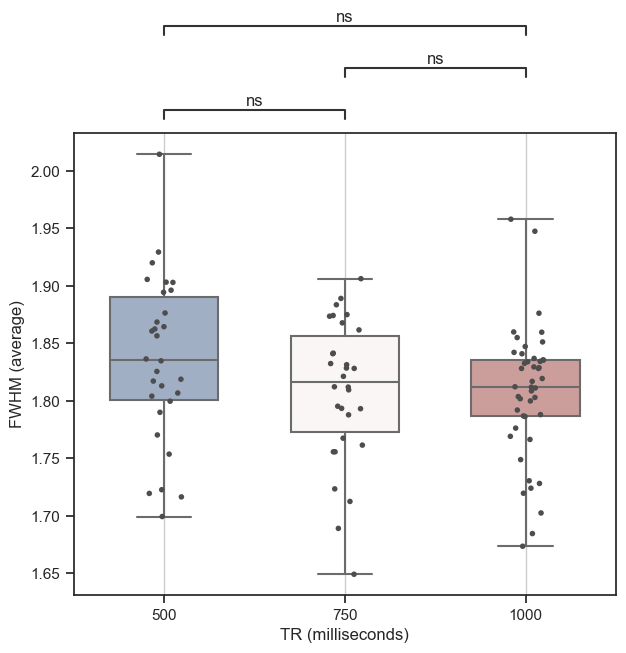

In [38]:
#| label: mriqc_fwhm
f